# HR Diagram

In [83]:
import urllib.request
urllib.request.urlretrieve("https://raw.githubusercontent.com/nshaud/ml_for_astro/main/stars.csv", "stars.csv")
import pandas as pd

In [6]:
df_stars = pd.read_csv(r"C:\Users\ricca\Documents\Unimib-Code\AstroStatistics\Notebooks\Data\stars.csv")

Quick data exploration

In [7]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
# Assign unique integers from 0 to 6 to each star type
df_stars['Star type'] = le.fit_transform(df_stars['Star type'])
labels = le.inverse_transform(df_stars['Star type'])
class_names = le.classes_

In [11]:
import seaborn as sns
import sys
sys.path.append(r"C:\Users\ricca\Documents\Unimib-Code\AstroStatistics\Notebooks")
from Utilities import plot_settings
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Real Labels')

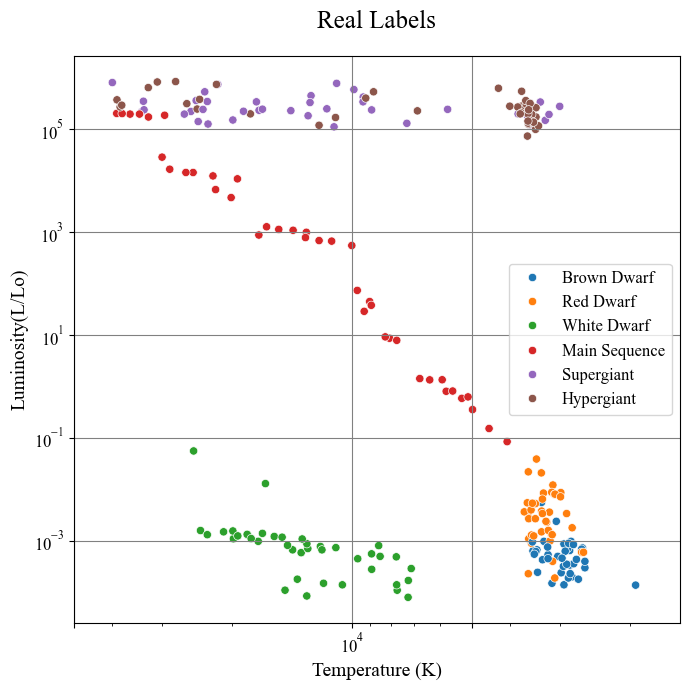

In [12]:
fig = plt.figure(figsize=(7, 7))
sns.scatterplot(data=df_stars, x='Temperature (K)', y='Luminosity(L/Lo)', hue=labels)
plt.xscale('log')
plt.yscale('log')
plt.xticks([5000, 10000, 50000])
plt.xlim(5e4, 1.5e3)
plt.title('Real Labels')

## PCA

In [13]:
import numpy as np
X = np.vstack([df_stars['Absolute magnitude(Mv)'].to_numpy(), df_stars['Luminosity(L/Lo)'].to_numpy(), df_stars['Radius(R/Ro)'].to_numpy(), df_stars['Temperature (K)'].to_numpy()]).T

In [14]:
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA

In [33]:
X_scaled = StandardScaler().fit_transform(X)
y = df_stars['Star type'].to_numpy()

In [ ]:
pca = PCA(n_components=4, random_state=32)
X_pca = pca.fit_transform(X_scaled)

Text(0, 0.5, 'Explained variance ratio')

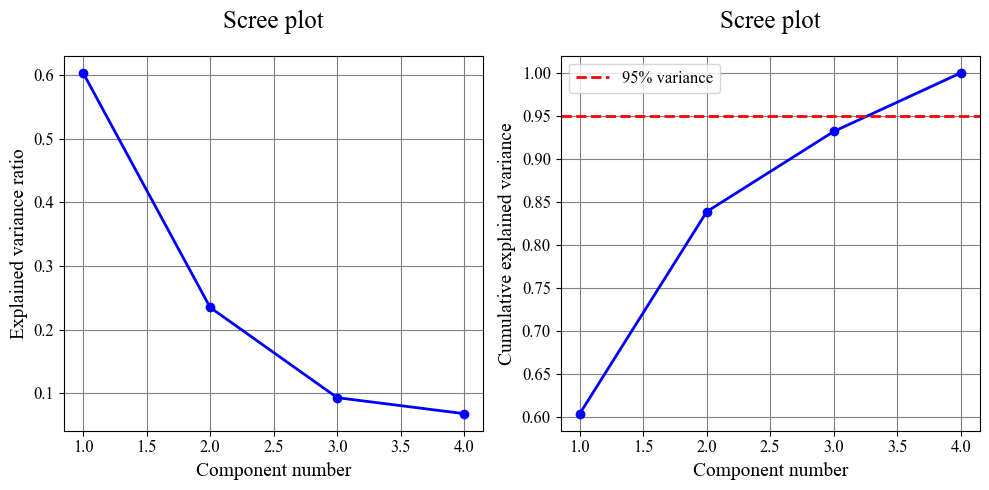

In [44]:
fig, axs = plt.subplots(1, 2)
axs[1].plot(range(1,pca.n_components+1), np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='-', color='blue')
axs[1].set_title('Scree plot')
axs[1].set_xlabel('Component number')
axs[1].axhline(0.95, 0, 1, linestyle='--', color='red', label='95% variance')
axs[1].set_ylabel('Cumulative explained variance')
axs[1].legend()

axs[0].plot(range(1,pca.n_components+1), pca.explained_variance_ratio_, marker='o', linestyle='-', color='blue')
axs[0].set_title('Scree plot')
axs[0].set_xlabel('Component number')
axs[0].set_ylabel('Explained variance ratio')

We can cluster now!\
I can do better, cross validate both on PCA components number and on number of components of GM model

In [74]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier

In [110]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, labels, test_size=0.3, shuffle=True, random_state=42)

In [111]:
pca = PCA(n_components=3)
X_pca_train = pca.fit_transform(X_train)
X_pca_test = pca.fit_transform(X_test)

In [112]:
# Define pipeline
pipe = Pipeline([
    ('cluster', KNeighborsClassifier(weights='distance', p=2))
])

# Hyperparameter grid to search
param_grid = {
    'cluster__n_neighbors': [2, 3, 5, 7, 10],
}

custom_cv = KFold(n_splits=10, shuffle=True, random_state=42)

In [113]:
# Grid search with accuracy scoring
grid = GridSearchCV(pipe, param_grid, cv=custom_cv, scoring='accuracy', verbose=3, refit=True, return_train_score=True)
grid.fit(X_pca_train, y_train)

Fitting 10 folds for each of 5 candidates, totalling 50 fits
[CV 1/10] END cluster__n_neighbors=2;, score=(train=1.000, test=0.941) total time=   0.0s
[CV 2/10] END cluster__n_neighbors=2;, score=(train=1.000, test=1.000) total time=   0.0s
[CV 3/10] END cluster__n_neighbors=2;, score=(train=1.000, test=1.000) total time=   0.0s
[CV 4/10] END cluster__n_neighbors=2;, score=(train=1.000, test=1.000) total time=   0.0s
[CV 5/10] END cluster__n_neighbors=2;, score=(train=1.000, test=1.000) total time=   0.0s
[CV 6/10] END cluster__n_neighbors=2;, score=(train=1.000, test=1.000) total time=   0.0s
[CV 7/10] END cluster__n_neighbors=2;, score=(train=1.000, test=1.000) total time=   0.0s
[CV 8/10] END cluster__n_neighbors=2;, score=(train=1.000, test=1.000) total time=   0.0s
[CV 9/10] END cluster__n_neighbors=2;, score=(train=1.000, test=1.000) total time=   0.0s
[CV 10/10] END cluster__n_neighbors=2;, score=(train=1.000, test=1.000) total time=   0.0s
[CV 1/10] END cluster__n_neighbors=3;,

,estimator,Pipeline(step...'distance'))])
,param_grid,"{'cluster__n_neighbors': [2, 3, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_neighbors,2


In [114]:
grid.cv_results_

{'mean_fit_time': array([0.00080581, 0.00198267, 0.        , 0.00156257, 0.00159216]),
 'std_fit_time': array([0.00196952, 0.0046496 , 0.        , 0.00468771, 0.00468204]),
 'mean_score_time': array([0.00422168, 0.00210812, 0.00236313, 0.00156124, 0.00031676]),
 'std_score_time': array([0.00475311, 0.00457535, 0.00502447, 0.00468371, 0.00095029]),
 'param_cluster__n_neighbors': masked_array(data=[2, 3, 5, 7, 10],
              mask=[False, False, False, False, False],
        fill_value=999999),
 'params': [{'cluster__n_neighbors': 2},
  {'cluster__n_neighbors': 3},
  {'cluster__n_neighbors': 5},
  {'cluster__n_neighbors': 7},
  {'cluster__n_neighbors': 10}],
 'split0_test_score': array([0.94117647, 1.        , 1.        , 1.        , 1.        ]),
 'split1_test_score': array([1., 1., 1., 1., 1.]),
 'split2_test_score': array([1., 1., 1., 1., 1.]),
 'split3_test_score': array([1.        , 0.88235294, 0.88235294, 0.88235294, 0.88235294]),
 'split4_test_score': array([1., 1., 1., 1., 1.]

In [115]:
predicted = grid.best_estimator_.predict(X_pca_test)

In [116]:
X_pca_train.shape

(168, 3)

In [117]:
df_train = pd.DataFrame({
    'F1' : X_pca_train[:,0],
    'F2' : X_pca_train[:,1],
    'F3' : X_pca_train[:,2],
    'true_labels' : y_train,
    'predicted': grid.best_estimator_.predict(X_pca_train)
})

df_test = pd.DataFrame({
    'F1' : X_pca_test[:,0],
    'F2' : X_pca_test[:,1],
    'F3' : X_pca_test[:,2],
    'true_labels' : y_test,
    'predicted': grid.best_estimator_.predict(X_pca_test)
})

Text(0.5, 1.0, 'Predicted Labels')

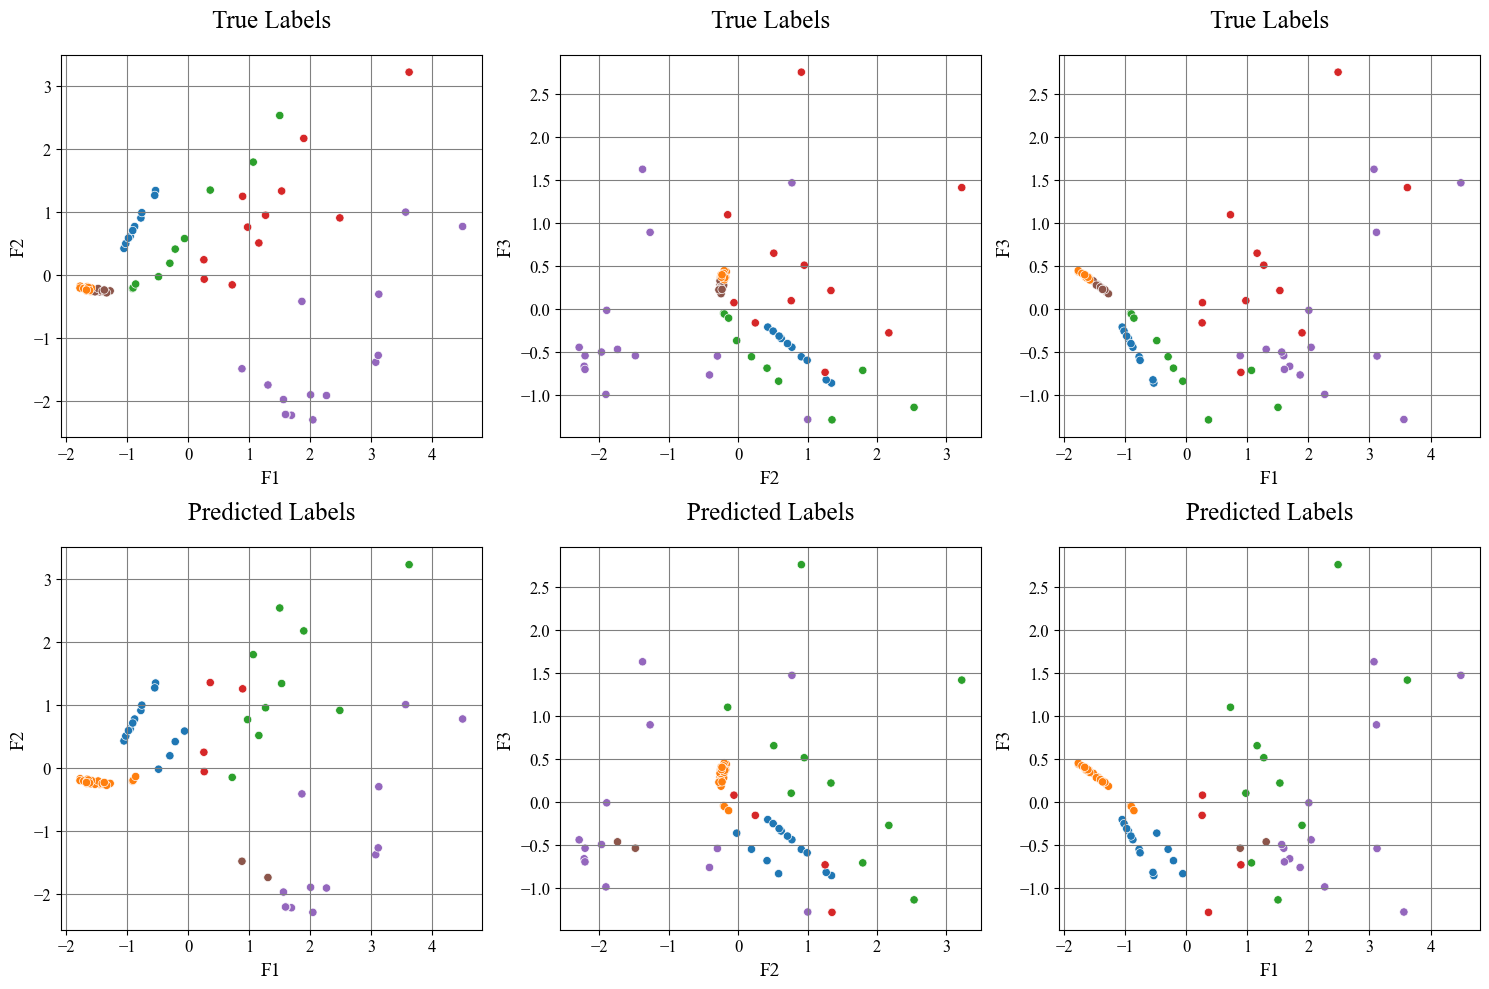

In [118]:
plt.figure(figsize=(15,10))
plt.subplot(2, 3, 1)
sns.scatterplot(data=df_test, x='F1', y='F2', hue='true_labels', legend=False)
plt.title('True Labels')

plt.subplot(2, 3, 2)
sns.scatterplot(data=df_test, x='F2', y='F3', hue='true_labels', legend=False)
plt.title('True Labels')

plt.subplot(2, 3, 3)
sns.scatterplot(data=df_test, x='F1', y='F3', hue='true_labels', legend=False)
plt.title('True Labels')

plt.subplot(2, 3, 4)
sns.scatterplot(data=df_test, x='F1', y='F2', hue='predicted', legend=False)
plt.title('Predicted Labels')

plt.subplot(2, 3, 5)
sns.scatterplot(data=df_test, x='F2', y='F3', hue='predicted', legend=False)
plt.title('Predicted Labels')

plt.subplot(2, 3, 6)
sns.scatterplot(data=df_test, x='F1', y='F3', hue='predicted', legend=False)
plt.title('Predicted Labels')